#  Random Forest Color Classifier

### derived using HST labels for the COSMOS field and CModel(r) < 26.0 (with colors corrected for ISM dust reddening)


In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib

In [3]:
path = Path.cwd().resolve()
for candidate in [path, *path.parents]:
    if (candidate / 'src').exists() and (candidate / 'paper_convergence').exists():
        repo_root = candidate
        break
else:
    raise RuntimeError('Could not locate repo root containing src/ and paper_convergence/')

for d in [repo_root / 'src', repo_root / 'paper_convergence' / 'code']:
    if str(d) not in sys.path:
        sys.path.insert(0, str(d))

import pipeline as pipl
import psf_cmodel_fit as pcf
from paper_plot_style import set_paper_style, save_figure

set_paper_style()
print(f'Repo root: {repo_root}')

Repo root: /Users/ivezic/Work/LSST/HeadScienceLSST/code/SGseparation/star-galaxy-separation


### read data

In [48]:
### this snippet must go to some py file...
def imputeColors(df, verbose=False):
    # for each color, if inf or NaN
    #    replace by a value drawn from the sample distribution
    colors = ['ug', 'gr', 'ri', 'iz', 'zy']
    for color in colors:
        if verbose: print('color:', color)
        valid = df.loc[np.isfinite(df[color]), color]
        mask = ~np.isfinite(df[color])
        if verbose: print('    replacing', mask.sum(), 'bad values')
        df.loc[mask, color] = np.random.choice(
            valid,
            size=mask.sum(),
            replace=True
        )

In [86]:
# fields = ['DP2_ECDFS_objects', 'DP2_COSMOS_objects']
# field_labels = ['ECDFS', 'COSMOS']

fields = ['DP2_ECDFS_objects']
field_labels = ['ECDFS']

data_dir = repo_root / 'data' / 'private'
data = [pipl.load_csv_dp2(str(data_dir / f'{f}.fits')) for f in fields]
data_mag = [pipl.magnitude_calculations(d, d['ebv'] * 3.10 / 1.20) for d in data]

for label, df in zip(field_labels, data_mag):
    print(f'{label}: {len(df):,} objects')

ECDFS: 732,402 objects


In [88]:
# replace colors whenever NaN or inf with a random value typical for other objects
data = data_mag[0]
imputeColors(data, True)

color: ug
    replacing 195901 bad values
color: gr
    replacing 47820 bad values
color: ri
    replacing 37148 bad values
color: iz
    replacing 44997 bad values
color: zy
    replacing 159551 bad values


In [109]:
# select subsamples defined by magnitude
magThreshold = 24
dataBright = data[(data['r_modelFlux_mag']>18)&(data['r_modelFlux_mag']<=magThreshold)]
dataFaint = data[(data['r_modelFlux_mag']>magThreshold)&(data['r_modelFlux_mag']<=magThreshold+1)] 
dataJunk = data[(data['r_modelFlux_mag']>magThreshold+1)&(data['r_modelFlux_mag']<=30)] 

## now apply RF classifier 

### read Random Forest Classifier 

In [110]:
# file with trained random forest model (140 MB)
RFfile = 'SG-COSMOS-HST-ColorRFclassifier_all.pkl'
clf = joblib.load(RFfile)

In [111]:
# only consider this magnitude-selected subset
df2classify = dataBright

In [112]:
features = ['ug', 'gr', 'ri', 'iz', 'zy']
X = df2classify[features].to_numpy()
pS = clf.predict_proba(X)[:, 1]

In [113]:
# separate stars and galaxies using default pS=0.5 threshold
# and inspect color-color diagrams
# also, compare to rExtendedness separation
# y = data['r_extendedness'].astype(int).to_numpy()
# random forest prediction (implicitly pS=0.5 threshold)
RFclass = clf.predict(X)
stars = X[RFclass==1]
gals = X[RFclass==0]
print(len(stars), len(gals))

8307 118842


## a few quick quality plots...

In [114]:
def plot2classCCD(SS, GG, c1, c2, xL, yL, xmin, xmax, ymin, ymax):
    plt.plot(GG[:, c1], GG[:, c2], 'o', ms=2, alpha=0.3, mew=0)
    plt.plot(SS[:, c1], SS[:, c2], 'o', ms=2, alpha=0.3, mew=0)

    plt.xlabel(xL)
    plt.ylabel(yL)
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

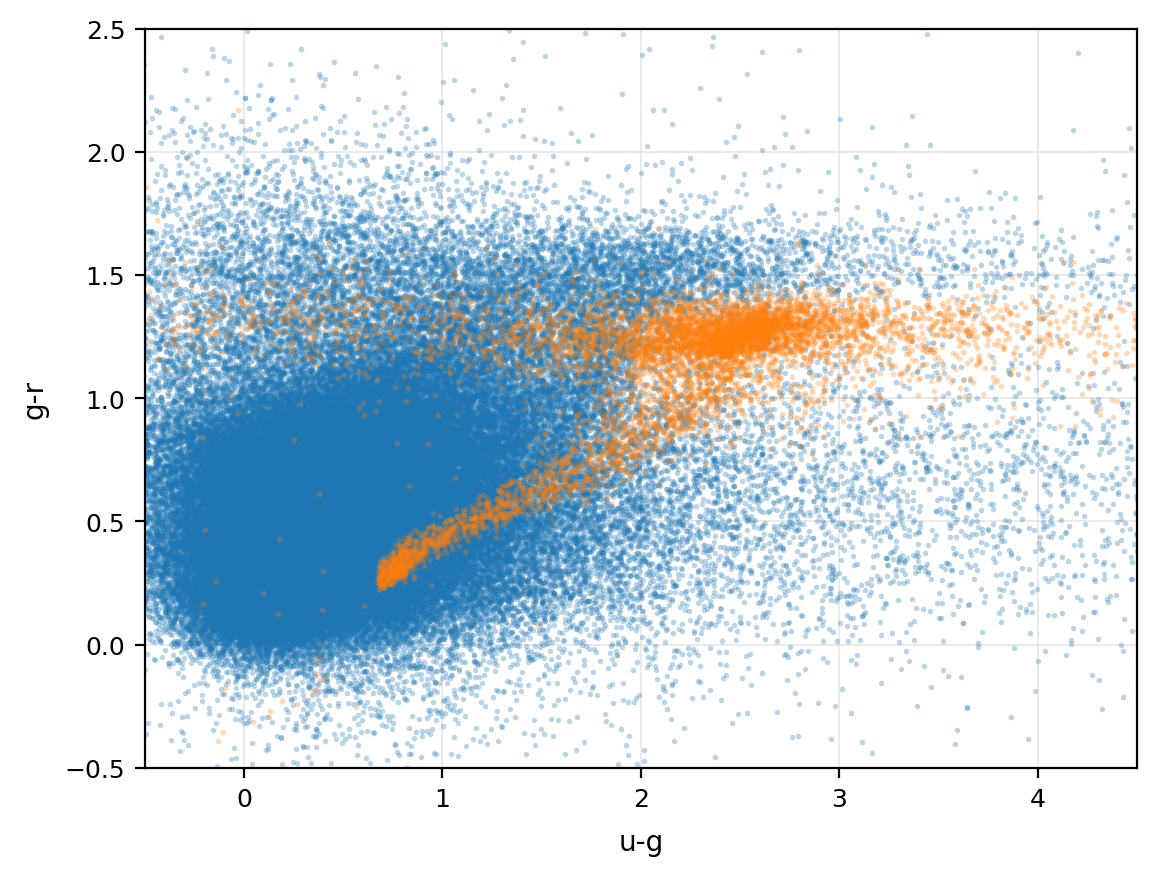

In [115]:
plot2classCCD(stars, gals, 0, 1, 'u-g', 'g-r', -0.5, 4.5, -0.5, 2.5)

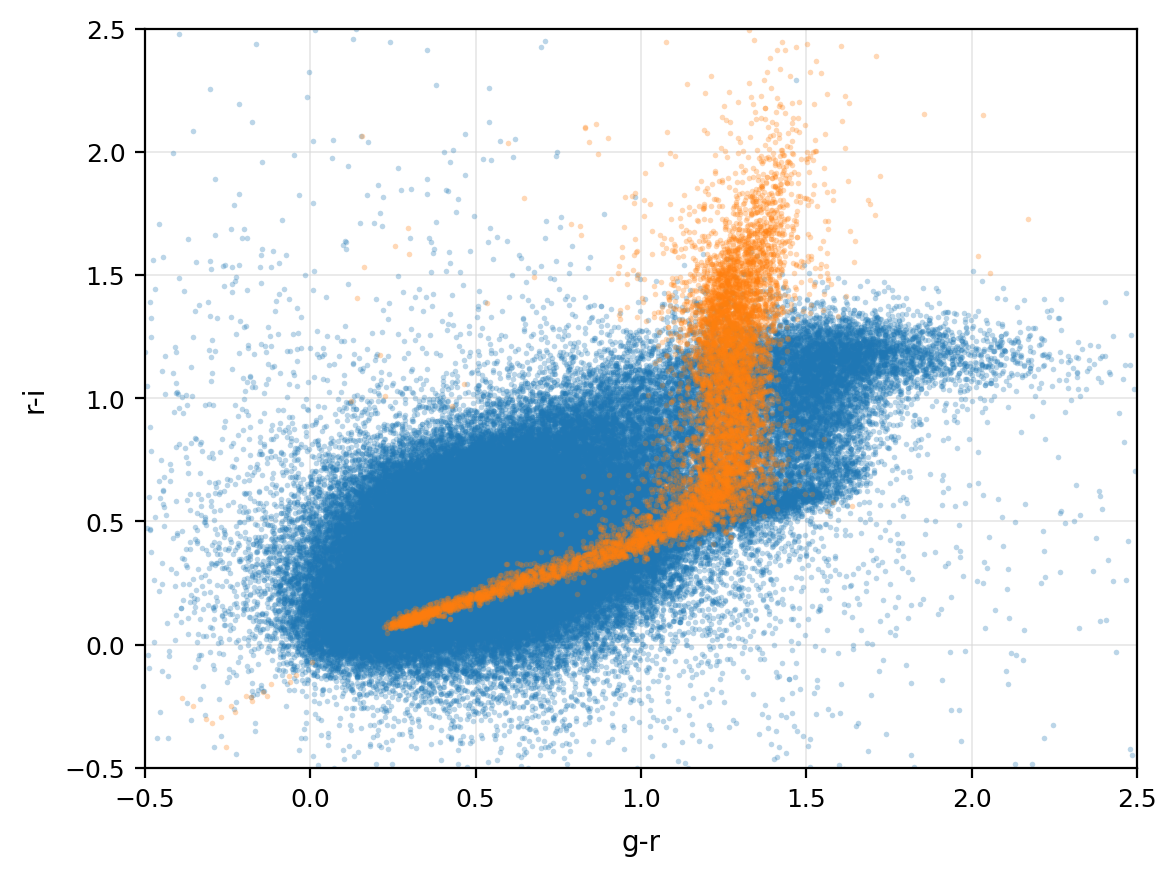

In [116]:
plot2classCCD(stars, gals, 1, 2, 'g-r', 'r-i', -0.5, 2.5, -0.5, 2.5)

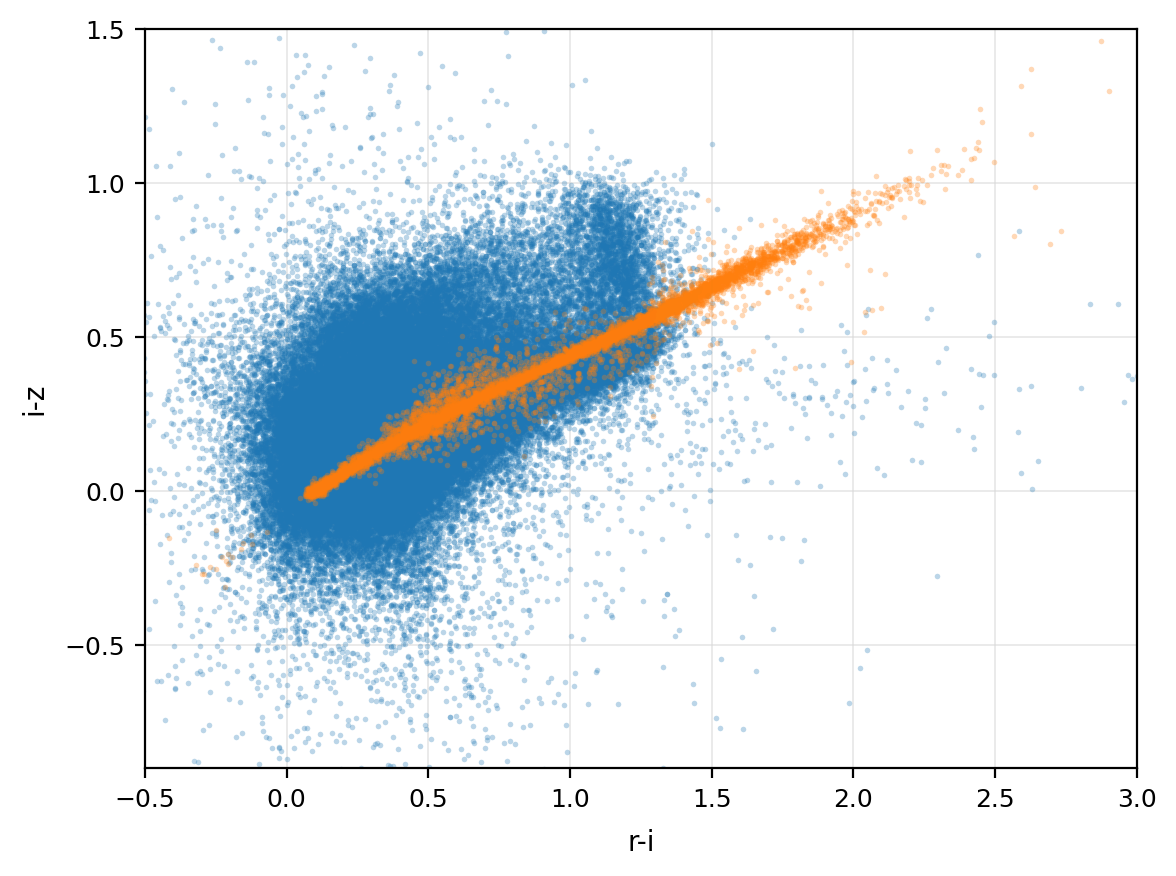

In [117]:
plot2classCCD(stars, gals, 2, 3, 'r-i', 'i-z', -0.5, 3.0, -0.9, 1.5)

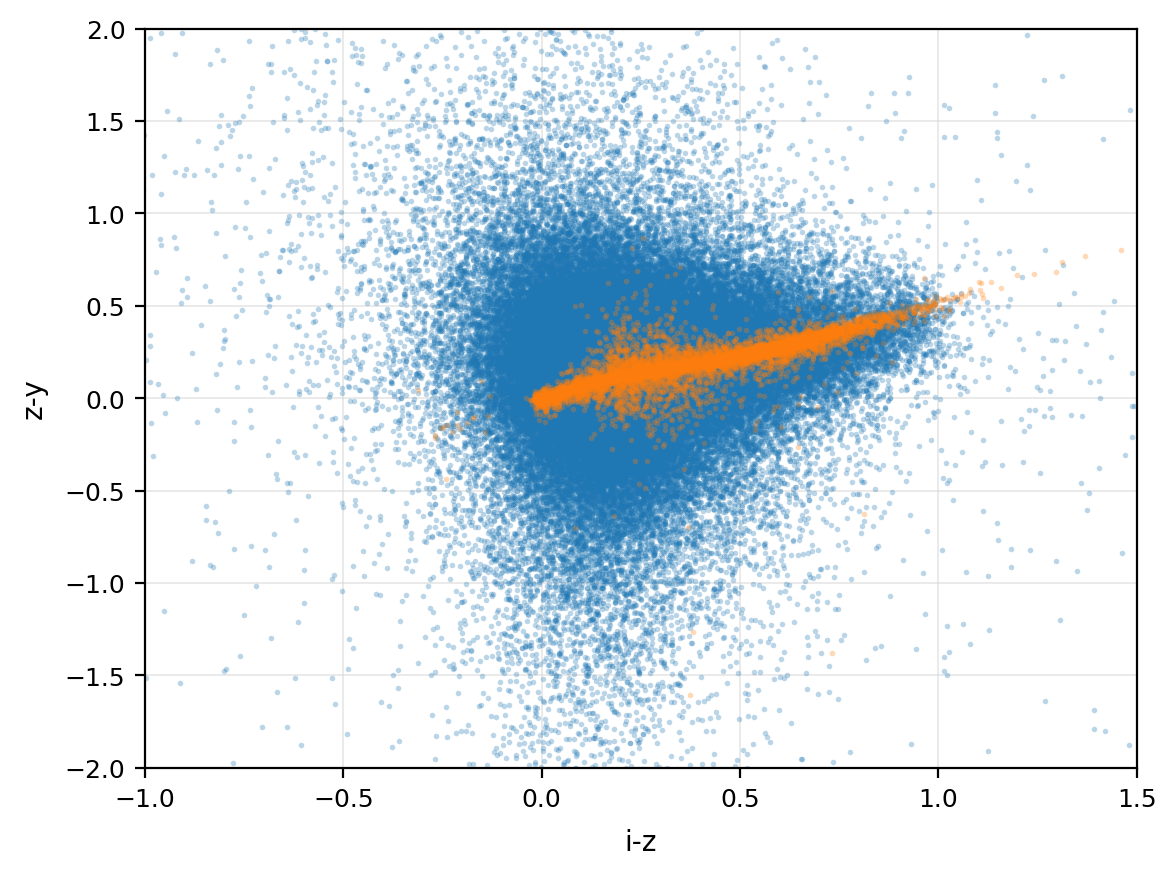

In [118]:
plot2classCCD(stars, gals, 3, 4, 'i-z', 'z-y', -1.0, 1.5, -2.0, 2.0)